### 예측모델 개념
과거 시계열 규칙으로 미래 값을 추정하는 것을 예측(Forecasting) 이라고 일컫는다.

## 예측 문제 정의
어떠한 내용을 예측하기 위해서는 모델을 선택하기 이전에 목표값과 예측기간, 평가지표가 무엇인지를 먼저 결정하여야 한다.

## 학습/평가 데이터 분리
모델을 학습(Fit)시키기 위해서는 데이터를 훈련용(Train)과 평가(Test) 데이터로 나누어야 한다. 시계열데이터는 예측 모델을 만들기 위해서는 데이터를 시간순서로 나누어야 한다. 시계열 데이터가 아닌 일반적인 데이터 같은 경우에는 데이터를 정려랗지 않고 사용해도 무방하나, 시간단위로 정렬하지 않은 상태로 훈련과 평가데이터를 나누었을 경우에는 평가용 데이터에 과거와 미래데이터가 혼재되어 포함될 수 있게 되고, 이렇게 평가에는 쓰이면 안되는 학습데이터가 섞여들어가는 경우를 데이터 누수(Data Leakage)라고 한다.

## 평가 지표
예측이 얼마나 맞았는지를 숫자로 나타내는 것이 평가 지표(Evaluation Metric)이다. 평가 지표중에서 가장 간단한 지표는 평균 절대오차(Mean Absolute Error, MAE)이다. 각 달의 실제값과 예측값의 차이를 절대값처리하여 평균계산 값이 MAE이다.

MAE는 규모가 다른 대상끼리는 비교하기 난해하다. 부산항에서 5만 TEU는 작은 오차일 수 있지만, 월 처리량이 10만 TEU인 다른 항구에서의 입장에서는 절반정도의 규모가 틀린 꼴이된다. 따라서 오차를 실제값으로 나눈 비율의 평균인 평균 절대 백분율오차(Mean Absolute Percentage Error, MAPE)를 같이 검토해볼 수 있다. 사이킷 런엣어는 mean_absolute_percentage_error() 함수를 호출해서 구할 수 있다.

## 회귀모델(Regression Model) - 선형 회귀(Linear Regression)
회귀 모델에서 기울기와 월 효과는 학습 데이터로부터 모델이 스스로 정하는 값(Coefficient, coef(계수))이고, 어떤 변수를 입력할지, 어떠한 규제를 줄지(하이퍼하라미터)는 사람이 결정하는 것이다.

## 과적합(Over fitting)
학습데이터의 모든 내용을 모델이 외워버리는 경우가 발생할 수 있다. 이렇게 학습용 데이터 전부를 외워버린 모델은 새로운 데이터를 만났을 때 정확도가 크게 낮아지는 현상이 발생할 수 있다. 이런 현상을 과적합(Over fitting)이라고 일컫는다. 학습시 오차는 적은데 평가시 오차가크다면 과적합을 의심해볼 수 있다.

선형 회귀 모델LinearRegrssion

사이킷런 선형모델 선형회귀모델

model <=

fit(X,Y) -> 회귀선

model predict -> 특정 X에 대한 Y값을 예측

### 시계열 전용 모델
회귀모델은 추세trend와 계절성을 사람이 변수로 만들어서 입력해야 한다.

시계열 전용 모델이 있는데 시계열 전용 모델은 최근 값과 최근 오차가 다음 값에 어떻게 이어지는가를 데이터에서 스스로 찾는다(학습한다).

- SARIMA
- 지수평활exponential smoothing

상기 두 가지 모델은 'statsmodels' 모듈에 구현되어 있다.


## SARIMA
ARIMA, AR(자기회귀autoregressive), I(누적integrated), MA(이동평균 오차moving average)

자기회귀는 지난 달 값이 높았으면 이번 달도 높다처럼 과거 값으로 현재를 설명하는 것이고 누적은 값 대신 전월과의 차이(차분)를 모델링해서 추세를 없애고 이동평균은 지난 달 예측이 빗나간만큼 이번달 값을 보정하겠다.

### SARIMA
SARIMA는 계절성이 있는 시계열을 예측하기 위해 ARIMA 모델에 계절성을 추가한 통계 모델이다.

## ARIMA(AutoRegressive Integrated Moving Average)
ARIMA는 시계열 데이터에서 과거 값과 과거의 예측 오차 사이에서 관계를 찾아 미래값을 예측하는 '통계모델'이다. ARIMA는 AR, I, MA의 조합이다. AR은 자기회귀(AutoRegressive)를 의미하고, I는 누적(Integrated), MA는 이동평균 오차(Moving Average)를 의미한다.

자기회귀(AutoRegressive)는 시계열의 현재 값을 그 자신의 과거 값들로 설명하는 회귀 모델을 의미한다. 자기(Auto)는 설명을 위한 변수가 다른 변수가 아니라 자기 자신의 과거라는 것을 의미한다. 가령, 일반 회귀가 '키로 몸무게를 예측한다'라고 한다면 자기회귀는 '어제의 기온으로 오늘의 기온을 예측한다'로 볼 수 있다.

월별 물동량을 예측한다고 가정하면, 지난달이나 두달 전 물동량이 이번 달 물동량과 어떤 관계를 갖는지 확인하는 것으로 볼 수 있다. 지난달 물동량이 평소보다 많았을 때, 이번달에도 많은 경향이 있다면, 지난 달의 값은 이번 달을 예측하는데 도움이 된다. 즉, 다른 변수 대신에 시계열에서의 과거 값을 사용해서 예측할 수 있다는 것이다. 회귀는 그 값들이 현재 값과 얼마나 관련되는지 게수로 표현한다는 것을 의미한다.

그러나 물동량이 해마다 증가하는 데이터(Trend)에 해당 관계를 바로 적용하면 문제가 발생한다. 몇 년 전에는 150만 TEU를 중심으로 해서 움직임이 있었는데 최근에는 200만 TEU를 중심으로 움직이게 되면 데이터의 평균 수준이 시간에 따라 달라지고 있기 때문이다. ARIMA는 필요한 경우에 원래 값에 차분을 적용한다. 차분(Differencing-역산은 증분, 누적)은 현재 값에서 이전 값을 빼는 연산이다. 월별 물동량이 190, 195, 200, 205면, 원래 값은 증가하지만 한 번 차분한 값은 5가 된다. 분석 대상을 물동량의 수준에서 매월 증가량으로 바꾼셈이다. 그래야 진짜 추세가 바뀌고 있는지 아닌지 확인할 수 있다.

I는 누적(Integrated)로서 누적에 해당한다. 차분한 데이터로 다음 달의 증가량을 예측하면, 실제로 필요한 물동량 예측값으로 돌릴 수 있어야한다. 가령, 마지막 물동량이 200이었고 익월 증가량을 4로 예측했다면 다음 달 물동량 예측은 204가 될수있어야 한다. 이처럼 예측한 변화량을 누적하여 원래단위의 값을 복원하는 역할을 담당한다고 정리할 수 있다.

MA는 이동평균(Moving Average)으로 과거의 예측 오차를 이용하는 것에 해당한다. 여기서 이동평균은 오차가 이후 값에 어떤 영향을 주는지를 표현한다.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
plt.rcParams['font.family'] = 'Malgun Gothic'

def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')

In [44]:
TARGET = '물동량_예측'

TEST_LEN = 24

ts = load_dataset(TARGET).pivot(index='연월', columns='수출입구분설명', values='물동량')
ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq('MS')
Y = ts.sum(axis=1, min_count=4).loc['2001-01':]

train, test = Y.iloc[:-TEST_LEN], Y.iloc[-TEST_LEN:]

In [45]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1), #
    seasonal_order=(0,1,1,12) #
).fit()

fc = sarima_model.get_forecast(TEST_LEN)

print(f'MAE = {mean_absolute_error(test, fc.predicted_mean)} TEU')
print(f'MAPE = {mean_absolute_percentage_error(test, fc.predicted_mean) * 100:.2f} %')
print(f'편향 = {(test - fc.predicted_mean).mean()}')

MAE = 141436.15945088878 TEU
MAPE = 6.99 %
편향 = 138340.15183473568


### 예측구간(Prediction Interval)
다음 달은 190~300 정도의 물동량일 가능성은 95%와 같이 범위로 말하는 예측을 예측 구간(Prediction Interval)이라고 일컫는다. 예측 구간은 모델의 가정이 맞다면이라는 전제조건 하에 붙는 범위이다. 따라서 현실에서 어떠한 특정 사건이 발생하면 예측은 맞았으나 실제 값이 구간 바깥으로 벗어나는 상황이 발생할 수도 있따.

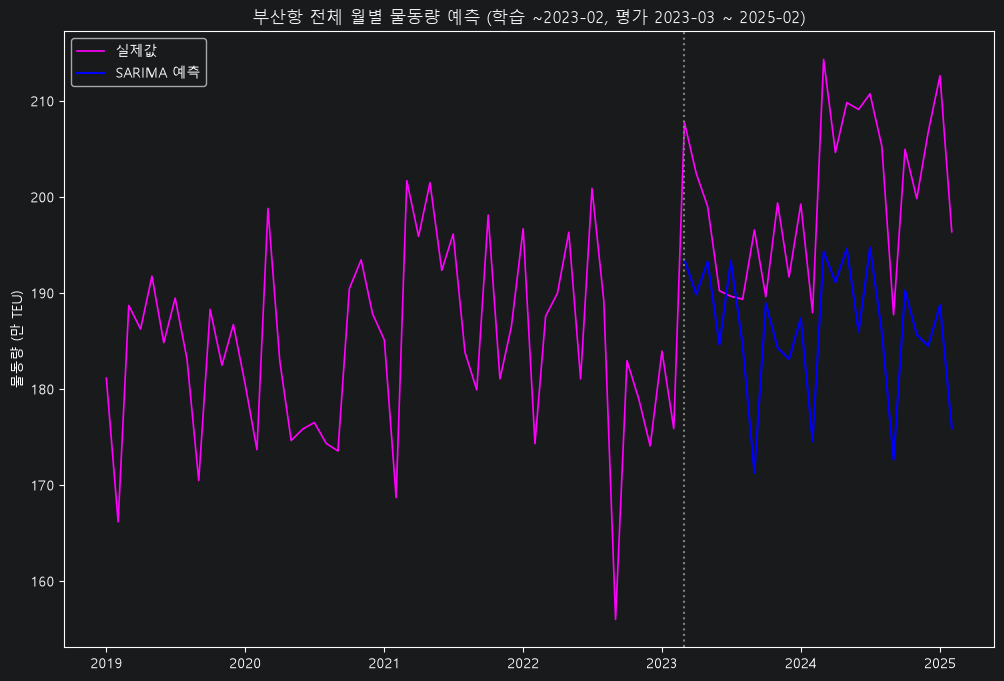

In [48]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(Y.loc["2019":] / 10_000, color="magenta", linewidth=1.2, label="실제값")
ax.plot(fc.predicted_mean / 10_000, color="blue", label="SARIMA 예측")

ax.axvline(test.index[0], color="gray", linestyle=":")

ax.set_ylabel("물동량 (만 TEU)")
ax.set_title("부산항 전체 월별 물동량 예측 (학습 ~2023-02, 평가 2023-03 ~ 2025-02)")

ax.legend()

plt.show()

평가 구간으로 모델과 차수를 선택한 다음에는 가장 최근 데이터까지 모두 사용하여 학습을 한 다음, 예측을 수행해볼 수 있다.

In [49]:
final_model = SARIMAX(
    Y,
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 12),
    trend="c"
).fit()

future = final_model.get_forecast(12) # 향후 12개월에 대한 예측

future_table = pd.DataFrame({
    "예측값": future.predicted_mean,
    "하한(95%)": future.conf_int(alpha=0.05).iloc[:, 0],
    "상한(95%)": future.conf_int(alpha=0.05).iloc[:, 1],
}).round(0)

print(future_table.head(3))

annual_2025 =Y.loc["2025"].sum() + future.predicted_mean.loc[:"2025-12"].sum()
print(round(annual_2025))

                  예측값    하한(95%)    상한(95%)
2025-03-01  2222381.0  2072990.0  2371773.0
2025-04-01  2162428.0  1980638.0  2344219.0
2025-05-01  2189665.0  1994200.0  2385129.0
25466947


In [50]:
# 매월 예측값 출력
for date, value in future.predicted_mean.items():
    print(f"{date:%Y-%m}, {value:.0f} TEU")

2025-03, 2222381 TEU
2025-04, 2162428 TEU
2025-05, 2189665 TEU
2025-06, 2132559 TEU
2025-07, 2173529 TEU
2025-08, 2117900 TEU
2025-09, 2010425 TEU
2025-10, 2131823 TEU
2025-11, 2116272 TEU
2025-12, 2120336 TEU
2026-01, 2180768 TEU
2026-02, 2042223 TEU


부산항 월별 컨테이너 물동량에 SARIMA 모델을 적합하여 2025년 3월부터 2026년 2월까지 12개월을 예측하였다. 월별 예측값은 약 201만~222만 TEU 범위로, 최고치는 2025년 3월(약 222만 TEU), 최저치는 2025년 9월(약 201만 TEU)로 나타났다.

예측기간의 월별 흐름을 보면, 2025년 3월 이후 8월까지 212만~222만 TEU 사이에서 등락을 반복하며 완만히 낮아지고, 9월에 약 201만 TEU로 크게 감소한 뒤 10월 약 213만 TEU로 반등한다. 11~12월은 약 212만 TEU 수준에서 보합을 보이다가 2026년 1월 약 218만 TEU로 높아지고, 2월에는 약 204만 TEU로 다시 낮아진다. 이러한 월간 등락은 모형이 과거 자료에서 학습한 계절 패턴을 반영한 것이므로, 연속된 월 사이의 증감을 물동량 추세의 변화로 해석할 수는 없다.

종합하면, 향후 12개월 부산항 물동량은 월 200만 TEU 이상의 규모에서 계절적 등락을 보일 것으로 전망되며, 선석,장비,인력 운영 계획에서는 월별 계절 변동과 명절 시기, 예측구간의 폭을 함께 반영할 필요가 있다.

# 모델의 평가 설계, 개선
모델이 예측한 결과를 얼마나 믿을 수 있는지를 따져볼 수 있는 도구가 필요하다. 이때 RMSE, ME, MASE 같은 평가 지표를 더하고 예측기간별로 오차를 나누어보는 롤링 원점 평가를 설계하고 로그변화 회귀, 계절시차 특성, 학습기간선택, 예측/결합 등의 방법으로 모델을 다듬을 수 있다.

## 지표
- RMSE root mean squared error평균제곱근 오차: 큰 오차가 얼마나 있는가?
- ME mean error편향: 한쪽으로 치우쳐져서 예측하는가?
- MASE mean absolute scaled error: 계절 나이브보다 얼마나 나은가?

### RMSE
RMSE는 오차를 제곱해서 평균을 구한 다음에 다시 제곱근을 씌운 값을 의미한다. 제곱을 하게되면 큰 오차가 더 커지게 된다. 그래서 RMSE를 구하게 되면 큰 오차에 민감하게 반응할 수 있게 된다.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygments.styles import native
from sklearn.linear_model import LinearRegression
plt.rcParams['font.family'] = 'Malgun Gothic'

def load_dataset(filename):
    BASE_DIR = './data'
    EXTENSION = '.csv'
    TARGET_PATH = f'{BASE_DIR}/{filename}{EXTENSION}'
    try:
        return pd.read_csv(TARGET_PATH)
    except FileNotFoundError:
        return None
    except UnicodeDecodeError:
        return pd.read_csv(TARGET_PATH, encoding='euc-kr')

In [38]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
# RMSE, MAE: 늘 조금씩 틀리는 예측, 가끔 크게 틀리는 예측

actual = np.full(12, 2_000_000)
steady = actual+ np.array([50_000, -50_000]*6)
spiky = actual.copy()
spiky[6] = actual[6] + 550_000
spiky = spiky +np.array([1_000]*6 + [0] + [1_000]*5)

errors = actual - spiky
print(f'MAE = {round(np.abs(errors).mean())}') #평균의 오류
#RMSE
#sqrt()
print(f'RMSE = {round(np.sqrt((errors ** 2).mean()))}')#잘못된 게 확 드러남, 큰 거에 제곱하면 뻥뛰기됨


MAE = 46750
RMSE = 158774


In [39]:
for name, pred in [('늘 조금씩 틀림', steady), ('가끔 크게 틀림', spiky)]:
    mae = mean_absolute_error(actual, pred) # 모델이 예측한 값
    rmse = root_mean_squared_error(actual, pred)
    print(f'{name} 모델의 MAE = {mae:,.0f} RMSE = {rmse:,.0f}')

늘 조금씩 틀림 모델의 MAE = 50,000 RMSE = 50,000
가끔 크게 틀림 모델의 MAE = 46,750 RMSE = 158,774


## 편향 bias
예측에서도 오차가 위아래로 고르게 흩어지는 것과 한쪽으로 몰릴 때 조치해야 되는 내용이 다르다. 한쪽으로 치우친 정도를 편향bias이라고 일컫는다. 오차에 절댓값을 씌우지 않고 그대로 평균을 구하게 되면 평균 오차ME mean error 라고 일컫는다.

편향이 양수이면 모델이 실제보다 작게 예측하는 경향이 있고 음수면 크게 예측하는 경향이 있다. MAE 가운데 편향이 차지하는 몫이 크면 모델이 추세나 수준을 잘못 잡고 있다고 판단할 수 있고 이러면 모델 구조를 고쳐야 된다. 편향이 0에 가깝고 MAE만 크면 설명하지 못하는 불규칙 변동이 크다고 볼 수 있다.

10만 , -10만의 오차가 합산되면 0이 된다. 편향이 없는 것처럼 보인다. 모델의 예측은 정확하지 않는 것이다. 편향은 편향만 구해서 사용하는 것이 아니라 MAE와 같이 사용한다.

- 편향 = 평균(실제값-예측값)
    - 양수: 과소 예측
    - 음수: 과대 예측

## MASE mean absolute scaled error
MAE가 5만 TEU라는 결과가 나왔을 때 해댱 지표가 좋은 지표인지 나쁜 지표인지를 판단하기 어렵다. 월 물동량 200만 TEU에서는 오차가 2.5% 정도이기 때문에 좋은 상태라고 판단해 볼 수 있지만 다른 수단으로 4만 TEU를 쉽게 구할 수 있었다면 이 지표는 좋지 않은 지표로 볼 수 있는 것이다.

MASE는 이러한 비교를 한 숫자로 만든 지표로서 모델의 MAE를 게절 나이브 학습 구간에서 보인 평균 오차로 나눈 값.

In [61]:
season = [-40, -120, 60, 40, 50, 10, 30, -10, -60,10, -10, -10]
# 48개월 변화량을 보여주는 것-패턴 매년 이런 움직임을 가짐
noise = np.random.default_rng(42).normal(0,15,48).round(0) #이걸 위에 넣음 42=난수 생성기 /난수 생성 알고리즘에 의해 씨드 결정
idx = pd.date_range('2021-01-01',periods=48,freq='MS')

toy = pd.Series([ 1900+5 * i + season[i % 12] for i in range(48)], index=idx) + noise
#1%12 모듈러 연산자 -> 12보다 클 수가 없음 0부터 11까지 게속 반복적으로 돌게 하기 위해
#계절 패턴 데이터

toy

2021-01-01    1865.0
2021-02-01    1769.0
2021-03-01    1981.0
2021-04-01    1969.0
2021-05-01    1941.0
2021-06-01    1915.0
2021-07-01    1962.0
2021-08-01    1920.0
2021-09-01    1880.0
2021-10-01    1942.0
2021-11-01    1953.0
2021-12-01    1957.0
2022-01-01    1921.0
2022-02-01    1862.0
2022-03-01    2037.0
2022-04-01    2002.0
2022-05-01    2036.0
2022-06-01    1981.0
2022-07-01    2033.0
2022-08-01    1984.0
2022-09-01    1937.0
2022-10-01    2005.0
2022-11-01    2018.0
2022-12-01    2003.0
2023-01-01    1974.0
2023-02-01    1900.0
2023-03-01    2098.0
2023-04-01    2080.0
2023-05-01    2096.0
2023-06-01    2061.0
2023-07-01    2112.0
2023-08-01    2039.0
2023-09-01    1992.0
2023-10-01    2063.0
2023-11-01    2069.0
2023-12-01    2082.0
2024-01-01    2038.0
2024-02-01    1952.0
2024-03-01    2138.0
2024-04-01    2145.0
2024-05-01    2161.0
2024-06-01    2123.0
2024-07-01    2130.0
2024-08-01    2108.0
2024-09-01    2062.0
2024-10-01    2138.0
2024-11-01    2133.0
2024-12-01   

In [62]:
train, test = toy.iloc[:36], toy.iloc[36:]
len(train)
len(test)

12

In [63]:
# 분모: 학습 구간에서 계절 나이브(12개월전 값)의 평균 절대 오차
scale = (train-train.shift(12)).abs().mean()
print(round(scale,1)) #매년 60정도의 오차가 난다

63.0


In [64]:
def mase(actual, pred, scale):
    return mean_absolute_error(actual, pred) /scale
# 실제 예측값의 MAE 계산후 scale로 나눗셈

In [65]:
seasonal_naive = train.iloc[-12:].to_numpy() #작년 값은 달 값 학습 데이터 마지막 12개월 (계절나이브로 활용)
with_growth = seasonal_naive + 12 * 5 # 작년 같은 달 +1년치 추세(월 5천 TEU * 12) 계절 나이브 예측값에 1년동안의 증가분 합산

In [66]:
mase(test, seasonal_naive, scale) #이게 더 좋은 데이터구나..)
mase(test, with_growth, scale)

np.float64(0.18253968253968253)

In [67]:
print(round(mase(test, seasonal_naive, scale), 2)) # 분모는 학습 구간의 오차, 분자는 평가 구간의 오차

0.91


In [68]:
print(round(mase(test, with_growth, scale), 2)) # 증가 추세를 더한 예측의 MASE

0.18


## 예측기간horizon
에측기간은 예측을 만든 시점에서 몇 칸 앞의 값을 예측하는가를 의미한다.

2월 말에 3월을 예측하면 1개월 앞에 있는 예측(h=1), 다음해 2월의 값을 예측 12개월(h=12)이 된다.

일기예보를 두고 볼 때 내일 것은 잘 맞는 편이나 열흘 뒤의 예보를 보면 상대적으로 잘 안 맞는다. 예측은 먼 미래일수록 그 사이에 생길 수 있는 일이 많아지기 때문에 오차가 커질 수 밖에 없다.

예측 오차는 예측 기간별로 따로따로 살펴 보아야 한다. MAE가 5만이다 보다는 1개월 앞의 MAE가 4만, 12개월 앞의 MAE는 7만이라는 내용이 잘 맞는 표현이다.

In [69]:
origin = train.index[-1] # 예측을 만드는 시점
print(origin)

2023-12-01 00:00:00


In [70]:
horizon = np.arange(1,13)
print(horizon)

[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [71]:
train.iloc[-1]

np.float64(2082.0)

In [72]:
naive = np.full(12, train.iloc[-1])
print(naive)

[2082. 2082. 2082. 2082. 2082. 2082. 2082. 2082. 2082. 2082. 2082. 2082.]


In [73]:

# 예측 기간과 방법별 절대오차를 담을 표 생성
abs_err = pd.DataFrame({
    'h': horizon,
    'naive': np.abs(test.to_numpy() - naive), # 각 달의 실제값에서 나이브 예측값을 차한뒤 절댓값 계산
    'seasonality naive': np.abs(test.to_numpy() - seasonal_naive) # 각 달의 실제값과 계절 나이브 예측값의 절대오차 계산
}).set_index('h').round(0) # h열을 인덱스 전환

abs_err

,naive,seasonality naive
h,,
1,44.0,64.0
2,130.0,52.0
3,56.0,40.0
4,63.0,65.0
5,79.0,65.0
6,41.0,62.0
7,48.0,18.0
8,26.0,69.0
9,20.0,70.0


### 베이스라인(Baseline)
베이스라인(Baseline)은 모델의 성능을 판단하기 위해 비교기준으로 사용하는 방법 혹은 모델을 의미한다. 예측 모델이 평균적으로 5만 TEU만큼 틀렸다고 하더라도, 그 값 만으로는 예측 모델의 정확도를 판단할 수 없다.

가령 모델 없이 그냥 간단한 방법만을 이용해서 예측하더라도 오차가 3만 TEU로 도출이 가능한 상황이라면, 해당 모델은 예상값의 차이만큼 잘못 예측한 꼴이 되는 것이다.

베이스라인은 하나의 특정 알고리즘이 아니라 비교기준으로 맡기는 역할을 의미한다. 따라서 데이터의 특징과 예측 몾걱에 맞는 방법을 베이스라인으로 선택한다.

### 계절 나이브(Seasonal Naive)
월별 물동량과 같이 매년 비슷한 시기에 반복되는 변화가 있는 데이터에는 계절 나이브(Seasonal Naive)를 베이스 라인으로 사용할 수 있다.

계절 나이브는 예측하려는 시점과 같은 계절(Season)에 해당하는 가장 최근 실제값을 그대로 예측값으로 사용하는 방법을 의미한다.

1년 주기로 계절성이 반복되는 월별 데이터라고 한다면, 작년동월값을 사용하는 것이다. 가령, 23년 2월의 물동량이 100이었다면, 24년 2월도 100으로 예측하고, 23년 3월이 150었다면 24년 3월도 150으로 예측하는 식이다.

계절 나이브 방식은 물동량이 매년 꾸준히 증가하거나(Trend) 갑작스러운 변화가 발생하면, 과거값을 그대로 사용하기 때문에 그 변화를 충분히 반영할 수 없다는 단점이 있다.

따라서, 계절 나이브를 베이스라인으로 사용하였다는 것은 검증을 위한 복잡한 모델을 따로 만드는 것이 아니라 작년 동월 값을 그대로 사용했을때보다 현재 모델이 더 잘 예측하는 것인가를 확인하고자 하는 것이다.

MASE에서도 계절 나이브를 비교 기준으로 활용할 수 있다. 다만, MASE의 분모는 학습 구간에서 계산한 계절 나이브의 편균 절대오차였다. 따라서 MASE가 0.5라는 것은 모델의 평가 오차가 그 학습 구간의 기준 오차의 절반이라는 것을의미한다.

모델의 실제 평가 기간에서도 계절 나이브보다 좋은지 나쁜지는 두 방법을 같은 평가 기간에 적용한 뒤 오차를 직접 비교하는 것이 권장된다.

비교를 위한 기준선 정도로 사용할 수 있다.

## 롤링 원점 평가
롤링원점평가는 예측을 시작하는 시점(원점)을 한달씩 뒤로 옮기면서 매번 원점까지의 데이터 학습, 원점 뒤 h개월 예측, 실제값과 비교를 반복.

In [36]:
def seasonal_naive_forecast(history , horizon):
        """과거 데이터와 예측 길이를 받아서 계절 나이브 예측값을 반환(독스크린-함수에 대한 설명을 씀)

    Args: 매개 변수를 쓰고 인센턴스- 어떤 예외가 발생하는지
        history: 해당 원점까지의 과거 데이터
        horizon: 앞으로 예측할 갯수

    Returns: 어떤 걸 반환하는지
        계절 나이브 예측값 배열

        과거 데이터의 마지막 12개월을 가져온 다음 앞에서부터 horizon개를 반환
        가령, 원점이 23년 3월이면 마지막 12개월은 22년 4월 ~ 23년 3월
        이중, horizon갯수만큼을 슬라이싱해서 반환
    """
    return history.iloc[-12:].to_numby()[:horizon]
# 램그래프-에이저트

def rolling_origin(s, forecaster, origins, horizon=12):
     """
    롤링 원점 평가 함수

    Args:
        s: 전체 시계열데이터
        forecaster: 사용할 예측 함수
        origins: 평가할 원점 목록
        horizon: 원점부터 예측할 갯수(기본값 12: 디폴트)

    Returns:
        평가 기록을 표(DataFrame)으로 반환
    """
    records = [] # 개별 평가 기록을 보관할 배열

    for origin in origins: # 원점을 하나씩 순회
        history = s.loc[:origin]  # 전체 데이터에서 원점까지의 데이터 선택
        future = s.loc[origin:]
        pred = forecaster(history, horizon)[:len(future)]
        for h, (date, actual_value) in enumerate(future.items(),start=1):
            records.append({'원점': origin, 'h': h, '날짜': date, '실제값': actual_value, '예측값': pred[h-1]})
    return pd.DataFrame(records)

In [74]:
def seasonal_naive_forecast(history, horizon):
    """과거 데이터와 예측 길이를 받아서 계절 나이브 예측값을 반환

    Args:
        history: 해당 원점까지의 과거 데이터
        horizon: 앞으로 예측할 갯수

    Returns:
        계절 나이브 예측값 배열

        과거 데이터의 마지막 12개월을 가져온 다음 앞에서부터 horizon개를 반환
        가령, 원점이 23년 3월이면 마지막 12개월은 22년 4월 ~ 23년 3월
        이중, horizon갯수만큼을 슬라이싱해서 반환
    """
    return history.iloc[-12:].to_numpy()[:horizon]

def rolling_origin(s, forecaster, origins, horizon = 12):
    """
    롤링 원점 평가 함수

    Args:
        s: 전체 시계열데이터
        forecaster: 사용할 예측 함수
        origins: 평가할 원점 목록
        horizon: 원점부터 예측할 갯수(기본값 12)

    Returns:
        평가 기록을 표(DataFrame)으로 반환
    """
    records = [] # 개별 평가 기록을 보관할 배열

    for origin in origins:  # 원점을 하나씩 순회
        history = s.loc[:origin] # 전체 데이터에서 원점까지의 데이터 선택
        future = s.loc[origin:].iloc[1:horizon + 1] # 원점 다음부터 실제값이 존재하는 구간을 선택
        pred = forecaster(history, horizon)[:len(future)]
        # seasonal_naive_forecast-forecaster
        # 과거 데이터로 예측값 생성후 실제 값이 있는 갯수만큼 슬라이싱 (iloc는 끝 위치가 데이터 길이를 넘어가도 존재하는 범위까지만 선택됨)

        # 원점이 24년 11월이면 예측값은 최대 12개지만, 확인할 실제값은 1이기 때문에 첫번째 예측값만 사용
        for h, (date, actual_value) in enumerate(future.items(), start=1): # 예측 대상 월을 하나씩 순회
            # h: 원점에서 h앞 개월 - horizon
            # date: 예측 대상 월
            # actual_value: 해당 월의 실제 값: 튜플
            records.append(
                {
                    '원점': origin, # 예측을 만든 시점
                    'h': h, # h개월
                    '날짜': date, # 예측 대상 시점
                    '실제값': actual_value, # 실제 값
                    '예측값': pred[h-1] # 예측된 값(인덱스이기 때문에 1차감) 자료형을 인덱스로 해야 하기에 차감
                }
            )
    return pd.DataFrame(records)
    # 딕셔너리에 배열을 넣게 되면 하나의 표가 나옴

"""
origins는 학습에 사용될 데이터 갯수가 아니라 예측을 만들어 평가할 시점들을 정하는 변수

가령 원점이 23년 1월이면 당월까지의 데이터를 이용하여 23년 2월부터 미래를 예측,
원점이 23년 2월로 이동하면 당월까지의 데이터를 이용하여 23년 3월부터 미래를 예측하는 방식
"""
# 원점을 origins에 넣은 거임
origins = toy.index[24:47] # 2023-01 ~ 2024-11, 전체 48개월 중 24~46인덱스까지를 선택
# 더 적게 뽑든 많게 뽑든 그렇게 되면 호라이즌 조절해야 // 원점 -롤링의 기점을 잘 정해야
backtest = rolling_origin(
    toy, # 전체 데이터
    seasonal_naive_forecast, # 계절 나이브 함수
    origins # 원점 목록
)

print(len(origins), len(backtest))
"""
23개 원점에서 모두 12개월을 사용하면 276개의 행이 나와야하지만, 마지막 원점은 실제값이 부족

따라서,

23년 1월~12월 -> 144
24년 1월~11월 -> 66
마지막에 1개월 정도가 모자람 - 롤링을 하다보면..
210개
"""

backtest['절대오차'] = (backtest['실제값'] - backtest['예측값']).abs() # 각 평가 기록에서 실제값과 예측값의 절대 차이를 계산하여 절대오차열 추가
# 절대오차 =  실제값에 측정값을 뺀 다음에 절대값

backtest.groupby('h')['절대오차'].mean().round(1) # 예측 기간(h)별로 묶어서 절대오차 평균을 계산하여 MAE 도출

23 210


h
1     60.2
2     61.2
3     61.2
4     60.4
5     60.4
6     59.3
7     58.1
8     58.3
9     58.5
10    58.6
11    59.2
12    57.5
Name: 절대오차, dtype: float64

이제까지 모델 평가하는 걸 했고 이제는 모델을 개선하는 방법을 배울 것

# 모델 개선
- 로그(log) 변환 회귀 : 23-24년까지 증가하는 추세인데 2월은 떨어지는 추세라면 절대적 양이 아니라 비율을 봐야함(%) 변화량 = 목표값에 로그를 취함 , 선형회귀로 볼 수 있음
- 계절 시차 특성: 부산항 물동량에서 자기상관-도드라지는 시간, 계절 등이 있음,작년 달 값이 올해 달 값을 잘 보여준다면 그 값을 회귀입력에 넣을 수 있음-이게 시차 특성 // 계절 시차를 회귀값에 넣는 것을 계절 시차 특성을 보여준다고 볼 수 있다
- 학습 기간 재선택:
- 예측 결합

선형회귀-지도학습: 데이터셋을 만들어서 집어넣음
데이터 속에서 패턴/관계를 찾아내는 게 군집학습-비지도 학습: 우린 데이터만 던져넣고

In [ ]:
log()